# QuantNado — end-to-end demo

This notebook covers the full QuantNado pipeline on a test dataset, using the GNAQ locus as the main running example:

| Section | What it shows |
|---|---|
| 1 Data | Download test BAM / bedGraph / VCF files |
| 2 Create | Write per-sample Zarr stores |
| 3 Combine | Stack stores into one multi-sample Zarr |
| 4 Explore | Properties, region slicing, DataTree |
| 5 Normalise | Library sizes, CPM, RPKM |
| 6 Locus plot | Genome-browser multi-omics tracks |
| 7 Reduce | GNAQ-focused signal summaries → heatmap + correlation |
| 8 Binned profiles | Fixed-width bins around GENE promoters → metaplot + tornadoplot |
| 9 Feature counts | DESeq2-compatible count matrix |
| 10 PCA | Dimensionality reduction across samples |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import plotnado as pn

import quantnado
from profiling.profiling import parse_logs, profile_combine, profile_stores
from quantnado.analysis.core import QuantNadoDataset

---
## Data

Test dataset: chr21-only BAM files (ATAC, ChIP, RNA, METH) plus a SNP VCF. The reference annotation is `chr21.gtf`, and we will derive GENE-focused examples from it throughout the notebook.

In [2]:
OUT_DIR = Path("profiling/test_output")
OUT_DIR.mkdir(exist_ok=True)

SAMPLES_DIR = OUT_DIR / "samples"
GTF_FILE = "local/test.gtf"
BED_FILE = "local/test_promoters.bed"
DATASET = OUT_DIR / "dataset.zarr"

# Build a tiny GENE-only GTF subset so downstream examples stay focused on one locus
GENE_NAME = "GNAQ"
GENE_CHROM = "chr9"
GENE_START = 77_714_097
GENE_END = 78_033_811
GENE_STRAND = "-"
GENE_LOCUS = f"{GENE_CHROM}:{GENE_START}-{GENE_END}"
GENE_PAD = 2_000

print(GENE_LOCUS, "strand=", GENE_STRAND)

chr9:77714097-78033811 strand= -


---
## Profiling

In [3]:
metadata = quantnado.metadata_from_seqnado("/Users/catherine/work/datasets")
metadata = metadata[metadata.sample_id.str.contains("SEM|RCH")]
metadata = metadata[~metadata.sample_id.str.contains("CM")]
metadata = metadata[~metadata.sample_id.str.contains("-3|-4|-5")]
metadata = metadata[metadata.ip.str.upper().isin(["MLLN", "H3K27AC", "TET2"]) | metadata.ip.isna()]
metadata.sort_values("sample_id", ascending=True, inplace=True)
metadata.reset_index(drop=True, inplace=True)
metadata.to_csv(OUT_DIR / "quantnado_metadata.csv", index=False)

In [4]:
profile_stores(metadata, output_path=SAMPLES_DIR, overwrite=False, test=True)

✓ ATAC-SEM-1
✓ ATAC-SEM-2
✓ CAT-RCHACV-1_MLLN
✓ CAT-RCHACV-2_MLLN
✓ CAT-RCHACV_H3K27ac
✓ CAT-RCHACV_TET2
✓ CAT-SEM-1_MLLN
✓ CAT-SEM-2_MLLN
✓ CAT-SEM_H3K27ac
✓ ChIP-RCHACV_MLLN
✓ ChIP-SEM_H3K27ac
✓ ChIP-SEM_MLLN
✓ ChIP-SEM_TET2
✓ RNA-RCHACV-1
✓ RNA-RCHACV-2
✓ RNA-SEM-1
✓ RNA-SEM-2
✓ TAPS-RCHACV
✓ TAPS-SEM
✓ gDNA-RCHACV
✓ gDNA-SEM


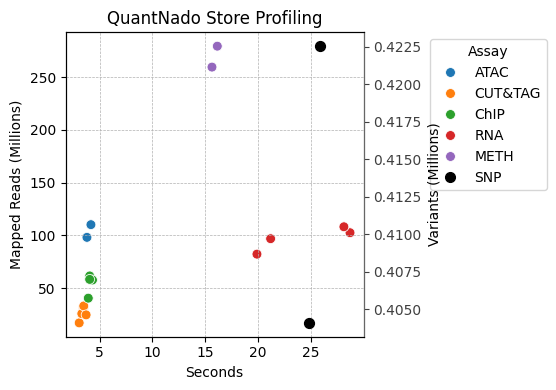

In [5]:
profile_df = parse_logs(metadata=metadata, output_dir=OUT_DIR, stores=SAMPLES_DIR, plot=True)

In [6]:
qn = profile_combine(samples_dir=SAMPLES_DIR, output_path=DATASET, overwrite=False)

Loading existing combined dataset from profiling/test_output/dataset.zarr...


---
## Open & explore

`QuantNadoDataset` auto-detects the layout (directory of per-sample stores **or** a single combined store) — the same API works for both.  
Pass `annotation=` to a GTF to enable gene-name-based access.

In [7]:
qn = QuantNadoDataset(DATASET)

In [ ]:
qn.group_by(
    ip="ip",
    cell_type={
        "SEM": ["SEM"],
        "RCH-ACV": ["RCHACV"],
    },
    replicate={
        "rep1": ["-1"],
        "rep2": ["-2"],
    },
    match="contains",
)
qn.subset(
    group={
        "cell_type": "SEM",
    },
)

In [22]:
qn.info

DatasetInfo
  assays      : ATAC, CHIP, CUT&TAG, METH, RNA, SNP
  chromosomes : chr13, chr21, chr9
  chromsizes  : chr9=138,394,717, chr13=114,364,328, chr21=46,709,983

  layout      : combined
  path        : profiling/test_output/dataset.zarr
  subset      : False
  groups
    ip       : MLLN, H3K27ac, TET2 (3)
    cell_type: SEM, RCH-ACV (2)
    replicate: rep1, rep2 (2)
    assay    : ATAC, CUT&TAG, CHIP, RNA, METH, SNP (6)

  ATAC
    n        : 2
    samples   : ATAC-SEM-1, ATAC-SEM-2
    keys      : coverage

  CHIP
    n        : 4
    samples   : ChIP-RCHACV_MLLN, ChIP-SEM_H3K27ac, ChIP-SEM_MLLN, ChIP-SEM_TET2
    keys      : coverage
    ips       : MLLN, H3K27ac, TET2

  CUT&TAG
    n        : 7
    samples   : CAT-RCHACV-1_MLLN, CAT-RCHACV-2_MLLN, CAT-RCHACV_H3K27ac, CAT-RCHACV_TET2, CAT-SEM-1_MLLN, CAT-SEM-2_MLLN, CAT-SEM_H3K27ac
    keys      : coverage
    ips       : MLLN, H3K27ac, TET2

  METH
    n        : 2
    samples   : TAPS-RCHACV, TAPS-SEM
    keys      : cove

---
## Accessing data

### Region slice → `xr.Dataset`

`qn.sel(chrom, start, end)` returns an `xr.Dataset` with dims `(sample, position)`. Coordinates are **1-based inclusive**.

In [10]:
region = qn.sel(chrom=GENE_CHROM, start=GENE_START, end=GENE_END)
region

<xarray.Dataset> Size: 379MB
Dimensions:       (sample: 21, position: 319715)
Coordinates:
  * sample        (sample) <U18 2kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
    assay         (sample) <U7 588B 'ATAC' 'ATAC' 'CUT&TAG' ... 'SNP' 'SNP'
  * position      (position) int64 3MB 77714097 77714098 ... 78033810 78033811
Data variables:
    AF            (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    coverage      (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    DP            (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    GT            (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    methyl_pct    (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    MQ            (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    n_methylated  (sample, position) float64 54MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    n_total       (sample, position) float64 54MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    rna_fwd       (sample, position) float64 54MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    rna_rev       (sample, position) float64 54MB dask.array<chunksize=(1, 319715), meta=np.ndarray>

In [11]:
# Select one sample — all data variables, 1D
region.sel(sample="ATAC-SEM-1")

<xarray.Dataset> Size: 20MB
Dimensions:       (position: 319715)
Coordinates:
  * position      (position) int64 3MB 77714097 77714098 ... 78033810 78033811
    sample        <U18 72B 'ATAC-SEM-1'
    assay         <U7 28B 'ATAC'
Data variables:
    AF            (position) float32 1MB dask.array<chunksize=(319715,), meta=np.ndarray>
    coverage      (position) float32 1MB dask.array<chunksize=(319715,), meta=np.ndarray>
    DP            (position) float32 1MB dask.array<chunksize=(319715,), meta=np.ndarray>
    GT            (position) float32 1MB dask.array<chunksize=(319715,), meta=np.ndarray>
    methyl_pct    (position) float32 1MB dask.array<chunksize=(319715,), meta=np.ndarray>
    MQ            (position) float32 1MB dask.array<chunksize=(319715,), meta=np.ndarray>
    n_methylated  (position) float64 3MB dask.array<chunksize=(319715,), meta=np.ndarray>
    n_total       (position) float64 3MB dask.array<chunksize=(319715,), meta=np.ndarray>
    rna_fwd       (position) float64 3MB dask.array<chunksize=(319715,), meta=np.ndarray>
    rna_rev       (position) float64 3MB dask.array<chunksize=(319715,), meta=np.ndarray>

In [12]:
# Sub-range within the region — still multi-sample
region.sel(position=slice(GENE_START, GENE_END))

<xarray.Dataset> Size: 379MB
Dimensions:       (sample: 21, position: 319715)
Coordinates:
  * sample        (sample) <U18 2kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
    assay         (sample) <U7 588B 'ATAC' 'ATAC' 'CUT&TAG' ... 'SNP' 'SNP'
  * position      (position) int64 3MB 77714097 77714098 ... 78033810 78033811
Data variables:
    AF            (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    coverage      (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    DP            (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    GT            (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    methyl_pct    (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    MQ            (sample, position) float32 27MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    n_methylated  (sample, position) float64 54MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    n_total       (sample, position) float64 54MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    rna_fwd       (sample, position) float64 54MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    rna_rev       (sample, position) float64 54MB dask.array<chunksize=(1, 319715), meta=np.ndarray>

### Gene-based access

With a GTF annotation loaded, `qn.gene_info()` returns gene metadata and `qn.sel_gene()` slices the dataset to the gene locus.

This cell also shows `load_gtf()`, a lower-level helper from `quantnado.analysis.features`, but most day-to-day analysis can stay on the `qn.*` API.

In [13]:
# add annotation info
qn.set_annotation(GTF_FILE)

gene = GENE_NAME
info = qn.gene_info(gene)
print(f"{gene}: {info['locus']}  strand={info['strand']}")

gene_region = qn.sel_gene(gene, padding=GENE_PAD)
gene_region

2026-04-11 18:41:07.559 | INFO     | quantnado.analysis.core:set_annotation:678 - Loaded annotation: 1,319 genes from local/test.gtf


GNAQ: chr9:77716097-78031972  strand=-


<xarray.Dataset> Size: 379MB
Dimensions:       (sample: 21, position: 319876)
Coordinates:
  * sample        (sample) <U18 2kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
    assay         (sample) <U7 588B 'ATAC' 'ATAC' 'CUT&TAG' ... 'SNP' 'SNP'
  * position      (position) int64 3MB 77714097 77714098 ... 78033971 78033972
Data variables:
    AF            (sample, position) float32 27MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    coverage      (sample, position) float32 27MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    DP            (sample, position) float32 27MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    GT            (sample, position) float32 27MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    methyl_pct    (sample, position) float32 27MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    MQ            (sample, position) float32 27MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    n_methylated  (sample, position) float64 54MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    n_total       (sample, position) float64 54MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    rna_fwd       (sample, position) float64 54MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
    rna_rev       (sample, position) float64 54MB dask.array<chunksize=(1, 319876), meta=np.ndarray>
Attributes:
    gene_name:    GNAQ
    gene_id:      ENSG00000156052.12
    gene_strand:  -
    locus:        chr9:77714097-78033972
    exons:        [{'start': 77716097, 'end': 77721513, 'exon_number': None},...

### Multiple assays

In [14]:
# Slice any chromosome node like a normal Dataset
assay_ds = qn.sel(GENE_CHROM, GENE_START, GENE_END, assay=["RNA", "ATAC"])
assay_ds

<xarray.Dataset> Size: 110MB
Dimensions:       (sample: 6, position: 319715)
Coordinates:
  * sample        (sample) <U18 432B 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'RNA-SEM-2'
    assay         (sample) <U7 168B 'ATAC' 'ATAC' 'RNA' 'RNA' 'RNA' 'RNA'
  * position      (position) int64 3MB 77714097 77714098 ... 78033810 78033811
Data variables:
    AF            (sample, position) float32 8MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    coverage      (sample, position) float32 8MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    DP            (sample, position) float32 8MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    GT            (sample, position) float32 8MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    methyl_pct    (sample, position) float32 8MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    MQ            (sample, position) float32 8MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    n_methylated  (sample, position) float64 15MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    n_total       (sample, position) float64 15MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    rna_fwd       (sample, position) float64 15MB dask.array<chunksize=(1, 319715), meta=np.ndarray>
    rna_rev       (sample, position) float64 15MB dask.array<chunksize=(1, 319715), meta=np.ndarray>

## Subset dataset

In [15]:
subset_assay = qn.subset(assay=["RNA", "ATAC"])
print(subset_assay.sample_names)

subset_sample = qn.subset(samples=["ATAC-SEM-1", "ATAC-SEM-2"])
print(subset_sample.sample_names)

['ATAC-SEM-1', 'ATAC-SEM-2', 'RNA-RCHACV-1', 'RNA-RCHACV-2', 'RNA-SEM-1', 'RNA-SEM-2']
['ATAC-SEM-1', 'ATAC-SEM-2']


---
## Normalisation

Library sizes are read directly from each store's `metadata/total_reads` array — no separate tracking needed.

In [16]:
lib_sizes = qn.library_sizes()
print(lib_sizes)

ATAC-SEM-1            110230100.0
ATAC-SEM-2             98190276.0
CAT-RCHACV-1_MLLN      32122714.0
CAT-RCHACV-2_MLLN      31207955.0
CAT-RCHACV_H3K27ac     25090650.0
CAT-RCHACV_TET2        17111963.0
CAT-SEM-1_MLLN         25881200.0
CAT-SEM-2_MLLN         33179048.0
CAT-SEM_H3K27ac        24713076.0
ChIP-RCHACV_MLLN       40555022.0
ChIP-SEM_H3K27ac       61621580.0
ChIP-SEM_MLLN          57777090.0
ChIP-SEM_TET2          58357470.0
RNA-RCHACV-1           82282121.0
RNA-RCHACV-2           96917722.0
RNA-SEM-1             102605603.0
RNA-SEM-2             108223434.0
TAPS-RCHACV           279429253.0
TAPS-SEM              259593290.0
gDNA-RCHACV              404094.0
gDNA-SEM                 422545.0
Name: library_size, dtype: float64


In [17]:
qn_cpm = qn.normalise(method="cpm")
region = qn_cpm.sel("chr21")
region["coverage"]
region["cpm"]

2026-04-11 18:41:11.297 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:11.327 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:11.352 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:11.369 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataset:426 - Added CPM variable(s) to xr.Dataset for coverage, rna_fwd, rna_rev.


<xarray.DataArray 'cpm' (sample: 21, position: 46709983)> Size: 8GB
dask.array<truediv, shape=(21, 46709983), dtype=float64, chunksize=(1, 33554432), chunktype=numpy.ndarray>
Coordinates:
  * sample    (sample) <U18 2kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
    assay     (sample) <U7 588B 'ATAC' 'ATAC' 'CUT&TAG' ... 'METH' 'SNP' 'SNP'
  * position  (position) int64 374MB 1 2 3 4 ... 46709981 46709982 46709983
Attributes:
    normalised:  cpm

In [18]:
qn_rpkm = qn.normalise(method="rpkm")
region = qn_rpkm.sel("chr21")
region["rpkm"]

2026-04-11 18:41:14.146 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to RPKM.
2026-04-11 18:41:14.176 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to RPKM.
2026-04-11 18:41:14.203 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to RPKM.
2026-04-11 18:41:14.219 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataset:426 - Added RPKM variable(s) to xr.Dataset for coverage, rna_fwd, rna_rev.


<xarray.DataArray 'rpkm' (sample: 21, position: 46709983)> Size: 8GB
dask.array<truediv, shape=(21, 46709983), dtype=float64, chunksize=(1, 33554432), chunktype=numpy.ndarray>
Coordinates:
  * sample    (sample) <U18 2kB 'ATAC-SEM-1' 'ATAC-SEM-2' ... 'gDNA-SEM'
    assay     (sample) <U7 588B 'ATAC' 'ATAC' 'CUT&TAG' ... 'METH' 'SNP' 'SNP'
  * position  (position) int64 374MB 1 2 3 4 ... 46709981 46709982 46709983
Attributes:
    normalised:  rpkm

2026-04-11 18:41:14.292 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:14.294 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:14.296 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:14.298 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataset:426 - Added CPM variable(s) to xr.Dataset for coverage, rna_fwd, rna_rev.


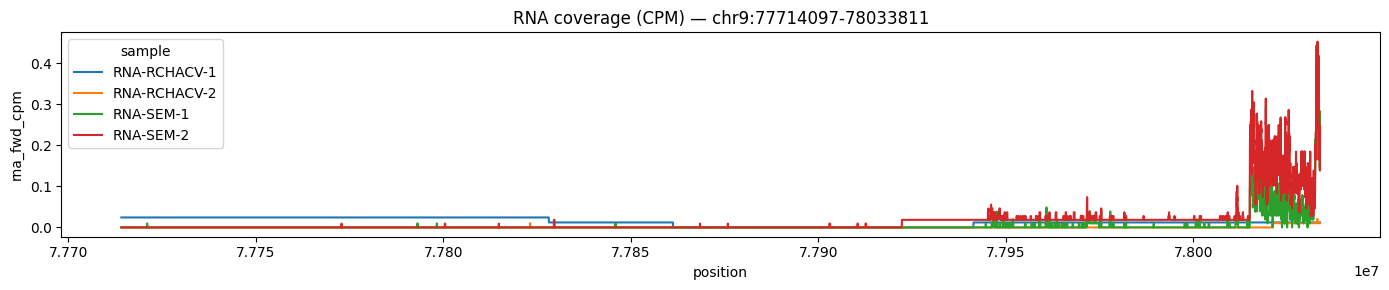

In [19]:
# Plot CPM-normalised RNA forward coverage, grouped by condition
rna_cpm = qn_cpm.subset(assay="RNA").sel(GENE_CHROM, GENE_START, GENE_END)

rna_cpm["rna_fwd_cpm"].plot.line(
    x="position",
    hue="sample",
    figsize=(14, 3),
)
plt.title(f"RNA coverage (CPM) — {GENE_LOCUS}")
plt.tight_layout()

---
## Locus plot

`qn.locus_plot()` gives a genome-browser-style multi-track view from the arrays returned by `qn.sel()`. Each track is rendered by its `modality`:

| modality | rendering |
|---|---|
| `coverage` | filled area (per-base depth) |
| `stranded_coverage` | mirrored strands — forward above zero, reverse below |
| `methylation` | scatter at CpG positions (methylation %) |
| `variant` | lollipop plot (allele frequency, coloured by genotype) |

2026-04-11 18:41:15.257 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:15.261 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:15.263 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:15.264 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataset:426 - Added CPM variable(s) to xr.Dataset for coverage, rna_fwd, rna_rev.


<QuantNadoAxesList n=21>

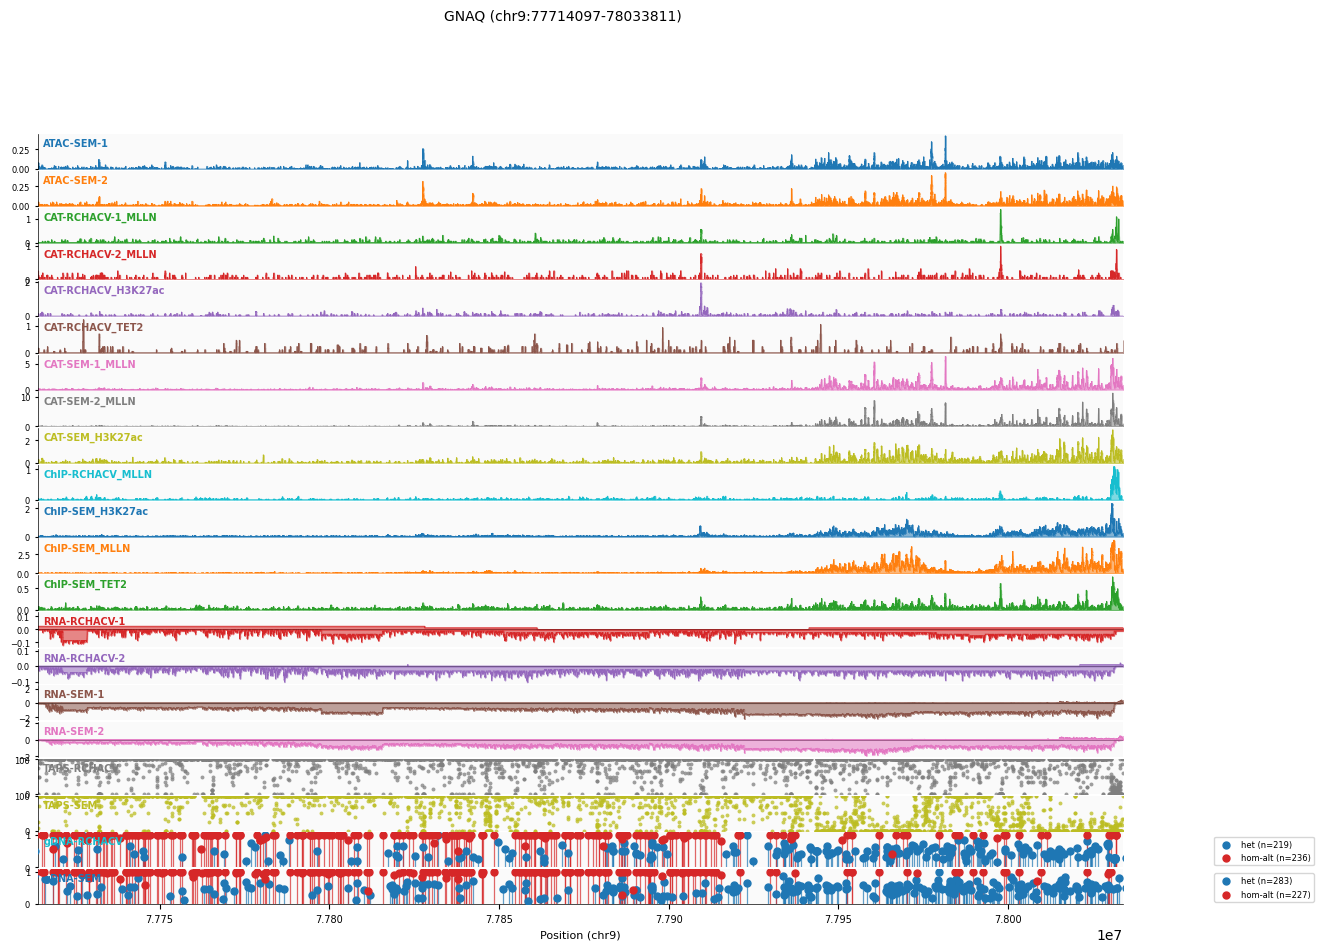

In [20]:
region = qn.sel(
    chrom=GENE_CHROM,
    start=GENE_START - GENE_PAD,
    end=GENE_END + GENE_PAD,
    assay=["ATAC", "ChIP", "CUT&TAG", "RNA", "METH", "SNP"],
)
region = qn.normalise(data=region, method="cpm")
sample_names = region.sample.to_series()

qn.locus_plot(
    locus=GENE_LOCUS,
    sample_names=region.sample.to_series().tolist(),
    coverage=region["cpm"],
    coverage_fwd=region["rna_fwd_cpm"],
    coverage_rev=region["rna_rev_cpm"],
    methylation=region["methyl_pct"],
    allele_freq=region["AF"],
    genotype=region["GT"],
    figsize=(14, 10),
    title=f"{GENE_NAME} ({GENE_LOCUS})",
)

---
### PlotNado

In [21]:
qn_cpm = qn.normalise(method="cpm")

groups = qn_cpm.groups
print("Groups:", groups)

Groups: GroupInfo
  ATAC      : ATAC-SEM-1, ATAC-SEM-2
  CUT&TAG   : CAT-RCHACV-1_MLLN, CAT-RCHACV-2_MLLN, CAT-RCHACV_H3K27ac, CAT-RCHACV_TET2, CAT-SEM-1_MLLN, CAT-SEM-2_MLLN, CAT-SEM_H3K27ac
  CHIP      : ChIP-RCHACV_MLLN, ChIP-SEM_H3K27ac, ChIP-SEM_MLLN, ChIP-SEM_TET2
  RNA       : RNA-RCHACV-1, RNA-RCHACV-2, RNA-SEM-1, RNA-SEM-2
  METH      : TAPS-RCHACV, TAPS-SEM
  SNP       : gDNA-RCHACV, gDNA-SEM


2026-04-11 18:41:49.510 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:49.574 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:49.751 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:49.819 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:49.989 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:50.053 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:50.210 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:41:50.273 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalis

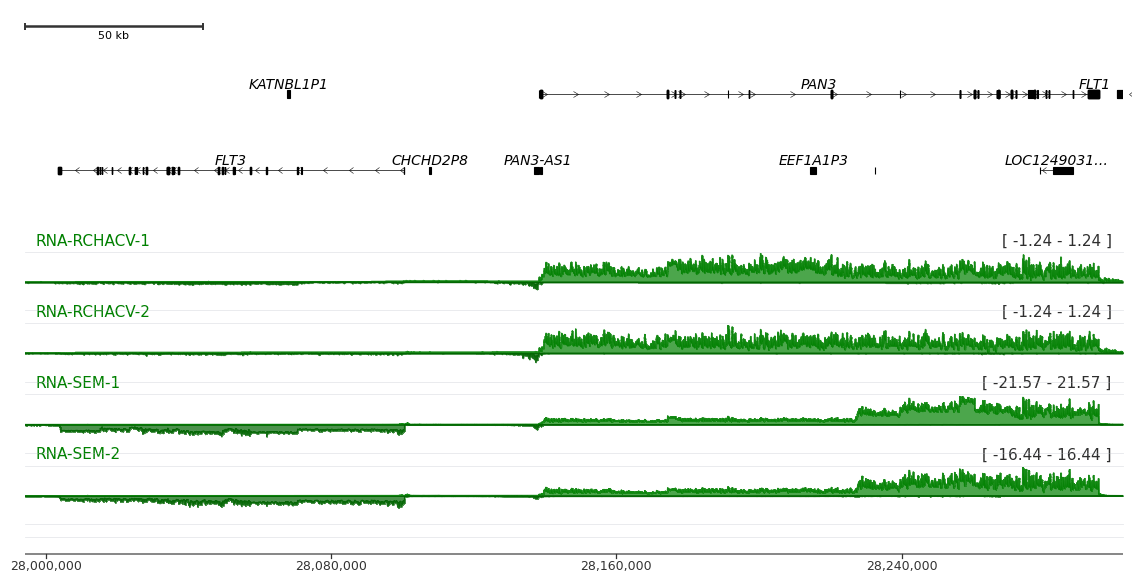

In [23]:
height = 0.5
gf = pn.GenomicFigure(theme="publication")
gf.scalebar()
gf.genes("hg38", display="expanded")
gf.spacer(height=0.3)
for sample in groups["RNA"]:
    gf.quantnado_stranded_coverage(
        sample,
        quantnado=qn_cpm,
        # autoscale_group="RNA",
        color="green",
        reverse_color="darkgreen",
        title=sample,
        height=height,
    )
    gf.spacer(height=0.1)
gf.axis()

flt3_pan3_locus = "chr13:27994000-28302000"
gf.plot(region=flt3_pan3_locus)

2026-04-11 18:43:33.417 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:33.548 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:33.701 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:33.851 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:33.992 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:34.126 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:34.260 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:34.386 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalis

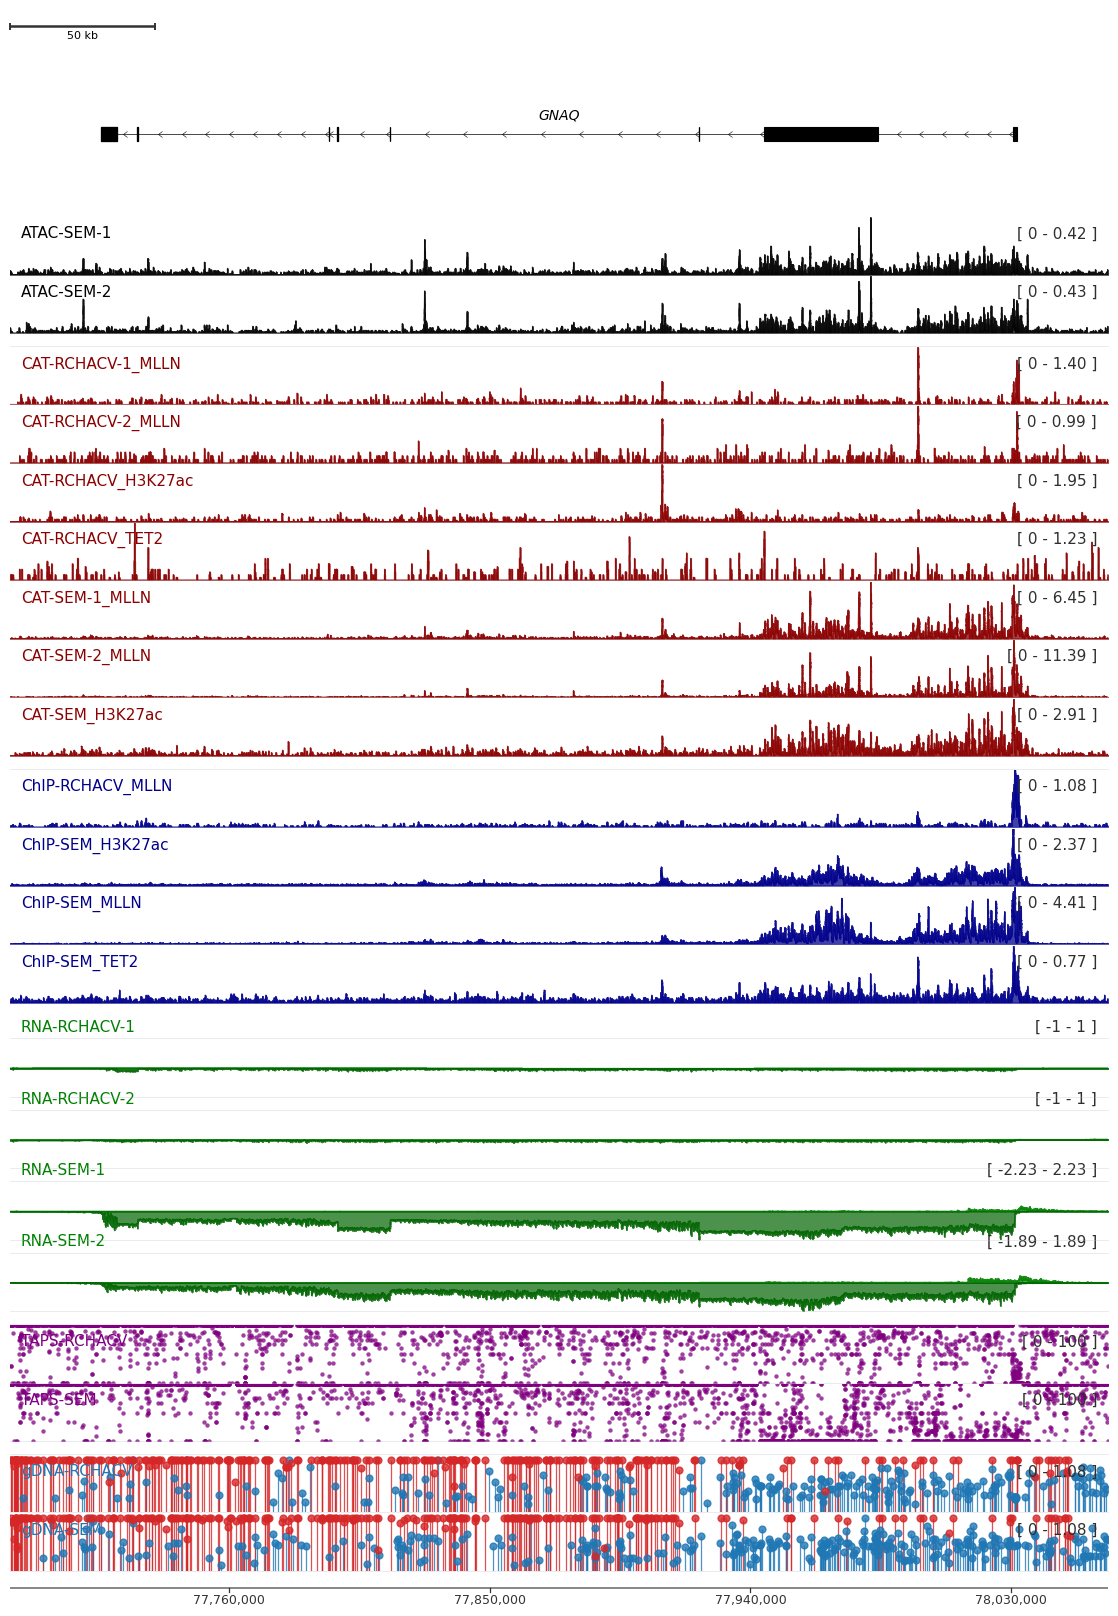

In [28]:
height = 0.5
gf = pn.GenomicFigure(theme="publication")
gf.scalebar()
gf.genes("hg38", minimum_gene_length=1e5, display="expanded")
for sample in groups["ATAC"]:
    gf.quantnado_coverage(
        sample,
        quantnado=qn_cpm,
        # autoscale_group="ATAC",
        color="black",
        title=sample,
        height=height,
    )
gf.spacer(height=0.1)
for sample in groups["CUT&TAG"]:
    gf.quantnado_coverage(
        sample,
        quantnado=qn_cpm,
        # autoscale_group="CAT",
        color="darkred",
        title=sample,
        height=height,
    )
gf.spacer(height=0.1)
for sample in groups["CHIP"]:
    gf.quantnado_coverage(
        sample,
        quantnado=qn_cpm,
        # autoscale_group="ChIP",
        color="darkblue",
        title=sample,
        height=height,
    )
gf.spacer(height=0.3)
for sample in groups["RNA"]:
    gf.quantnado_stranded_coverage(
        sample,
        quantnado=qn_cpm,
        # autoscale_group="RNA",
        color="green",
        reverse_color="darkgreen",
        title=sample,
        height=height,
    )
    gf.spacer(height=0.1)

for sample in groups["METH"]:
    gf.quantnado_methylation(
        sample,
        quantnado=qn_cpm,
        methylation_variable="methyl_pct",
        color="purple",
        title=sample,
        height=height,
    )
gf.spacer(height=0.1)
for sample in groups["SNP"]:
    gf.quantnado_variant(
        sample,
        quantnado=qn_cpm,
        genotype_variable="GT",
        title=sample,
        height=height,
    )
gf.axis()
gf.plot_gene("GNAQ", extend=0.1)

2026-04-11 18:43:47.711 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:47.811 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:47.912 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:48.008 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:48.148 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:48.240 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:48.330 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalised xr.DataArray to CPM.
2026-04-11 18:43:48.422 | INFO     | quantnado.analysis.normalise:_normalise_xr_dataarray:583 - Normalis

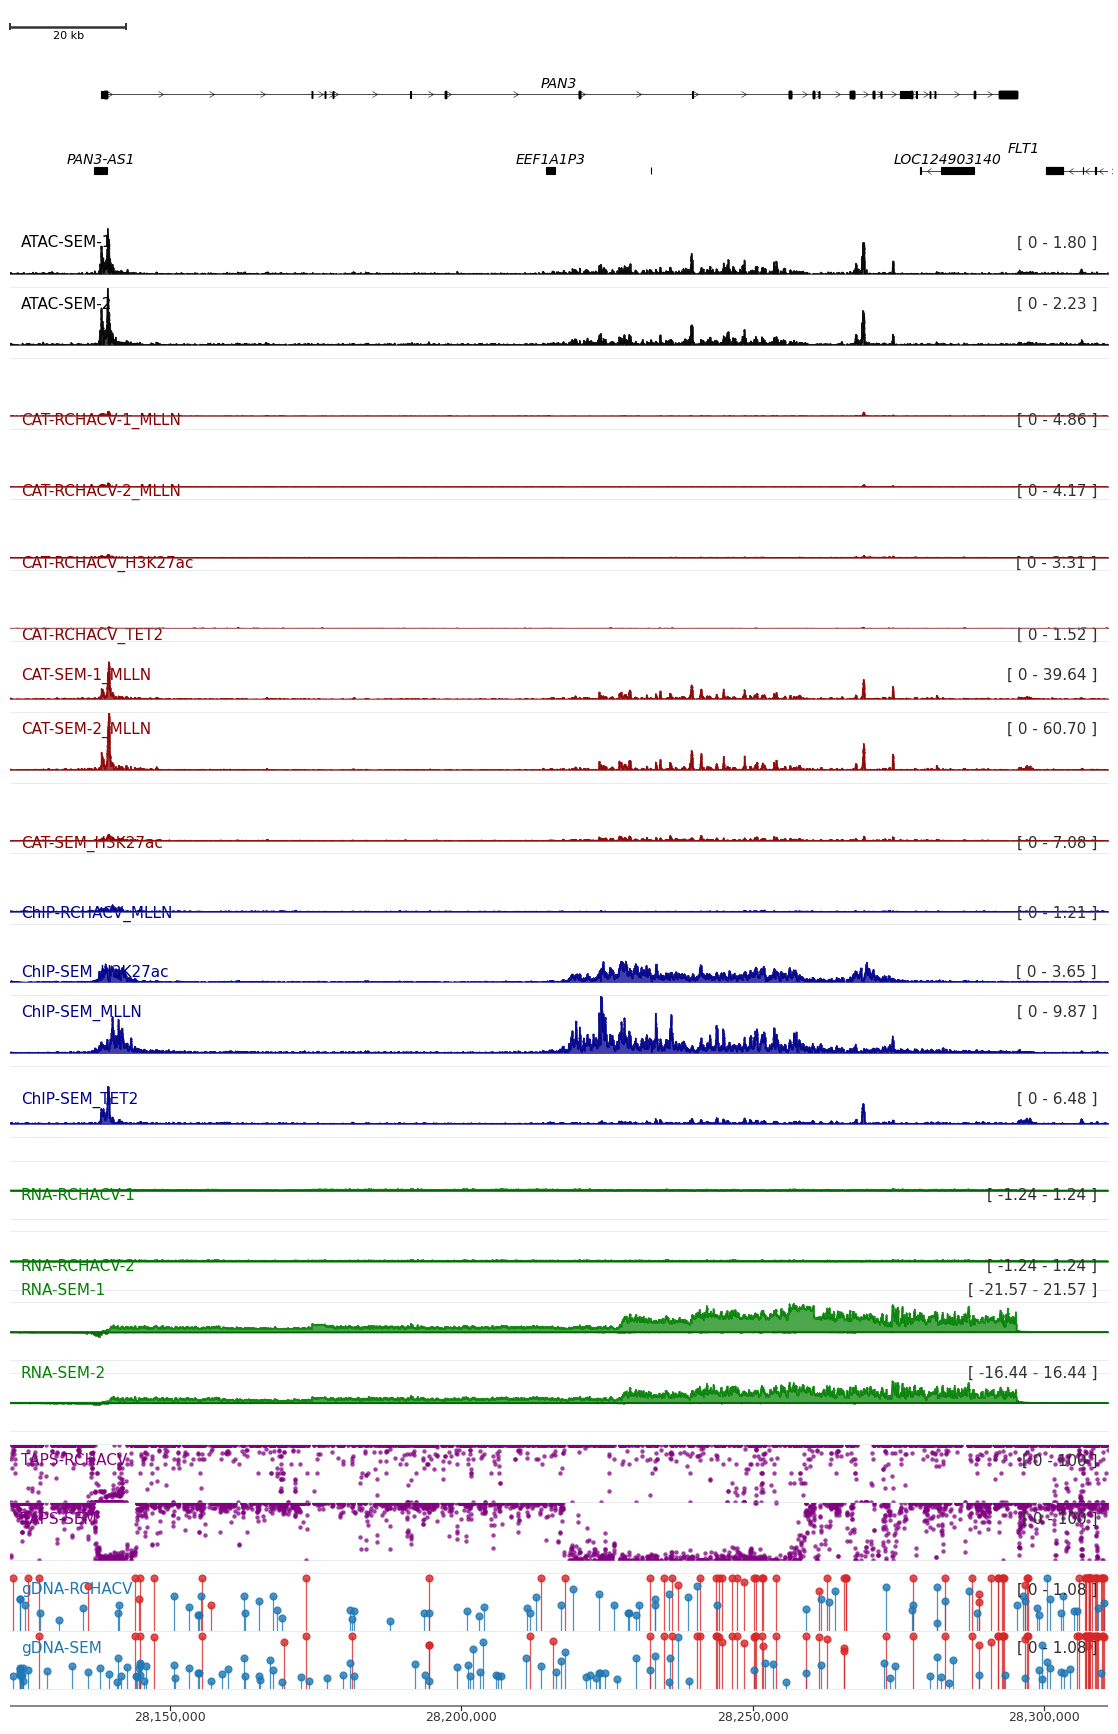

In [29]:
height = 0.5
gf = pn.GenomicFigure(theme="publication")
gf.scalebar()
gf.genes("hg38", display="expanded")
for sample in groups["ATAC"]:
    gf.quantnado_coverage(
        sample,
        quantnado=qn_cpm,
        autoscale_group="ATAC",
        color="black",
        title=sample,
        height=height,
    )
    gf.spacer(height=0.1)
for sample in groups["CUT&TAG"]:
    gf.quantnado_coverage(
        sample,
        quantnado=qn_cpm,
        autoscale_group="CUT&TAG",
        color="darkred",
        title=sample,
        height=height,
    )
    gf.spacer(height=0.1)
for sample in groups["CHIP"]:
    gf.quantnado_coverage(
        sample,
        quantnado=qn_cpm,
        autoscale_group="CHIP",
        color="darkblue",
        title=sample,
        height=height,
    )
    gf.spacer(height=0.1)
gf.spacer(height=0.2)
for sample in groups["RNA"]:
    gf.quantnado_stranded_coverage(
        sample,
        quantnado=qn_cpm,
        autoscale_group="RNA",
        color="green",
        reverse_color="darkgreen",
        title=sample,
        height=height,
    )
    gf.spacer(height=0.1)

for sample in groups["METH"]:
    gf.quantnado_methylation(
        sample,
        quantnado=qn_cpm,
        methylation_variable="methyl_pct",
        color="purple",
        title=sample,
        height=height,
    )
gf.spacer(height=0.1)
for sample in groups["SNP"]:
    gf.quantnado_variant(
        sample,
        quantnado=qn_cpm,
        genotype_variable="GT",
        title=sample,
        height=height,
    )
gf.axis()
gf.plot_gene("PAN3", extend=0.1)

---
## Reduce signal over Promoters

`qn.reduce()` efficiently summarises per-base signal over a BED file or feature set. Here we use a Promoter-only BED subset. The result is an `xr.Dataset` with dims `(ranges, sample)` — the right input for `heatmap` and `correlate`.

In [ ]:
# Reduce mean CHIP signal over GENE transcript bodies
chip = qn.subset(assay=["CHIP", "CUT&TAG"])
chip_rpkm = chip.normalise(method="rpkm")

promoters = chip_rpkm.reduce(
    intervals_path=str(BED_FILE),
    feature_type="transcript",
    modality="coverage",
    reduction="mean",
)
promoters

2026-04-11 18:44:06.755 | INFO     | quantnado.analysis.reduce:_log_chromosome_overlap:185 - Chromosome compatibility check: 3 shared chromosomes out of 3 in GTF and 3 in dataset
2026-04-11 18:44:06.755 | DEBUG    | quantnado.analysis.reduce:_log_chromosome_overlap:191 - Shared chromosomes: ['chr13', 'chr21', 'chr9']


In [ ]:
qn.heatmap(
    promoters,
    variable="mean",
    exclude_zeros=True,
    log_transform=True,
    zscore=0,
    title="Mean RPKM over promoters",
    figsize=(6, 7),
)

In [ ]:
corr_df, _ = qn.correlate(
    promoters,
    variable="mean",
    log_transform=True,
    method="pearson",
    title="RPKM sample correlation over promoters",
)

---
## Binned profiles → metaplot & tornadoplot

`qn.extract()` bins signal into fixed-width windows centred on genomic features such as promoters or transcripts. For a single gene, tornado plots are more informative when we anchor on transcript promoters rather than the single gene-level promoter, so this section uses `anchor_feature="transcript"`. The result is an `xr.DataArray` with dims `(interval, bin, sample)`, which is the natural input for `qn.metaplot()` and `qn.tornadoplot()`.

In [ ]:
# Extract ±2 kb around GENE transcript-promoter TSS windows in 50 bp bins — ATAC signal
binned = qn.extract(
    feature_type="promoter",
    GTF_FILE=str(GTF_FILE),
    anchor_feature="transcript",
    upstream=2000,
    downstream=2000,
    anchor="start",
    bin_size=50,
    assay="ATAC",
    modality="coverage",
)
print(binned.dims, binned.shape)

In [ ]:
# RPKM-normalise then plot the metaplot
binned_rpkm = qn.normalise(binned, method="rpkm")

qn.metaplot(
    binned_rpkm,
    error_stat="sem",
    reference_label="TSS",
    title=f"ATAC signal at {GENE_NAME} transcript promoters",
    figsize=(8, 4),
)

In [ ]:
# Tornadoplot — heatmap with one row per GENE promoter interval, sorted by mean ATAC signal
qn.tornadoplot(
    binned_rpkm,
    modality="coverage",
    sort_by="mean",
    reference_label="TSS",
    title=f"ATAC signal across {GENE_NAME} transcript promoters",
    figsize=(4, 4),
)

In [ ]:
# RNA — compare control vs treated at the same GENE transcript promoters
binned_rna = qn.extract(
    feature_type="promoter",
    GTF_FILE=str(GTF_FILE),
    anchor_feature="transcript",
    upstream=2000,
    downstream=2000,
    anchor="start",
    bin_size=50,
    assay="RNA",
    modality="coverage",
)


In [ ]:
binned_rna_cpm = qn.normalise(binned_rna, method="cpm")
qn.metaplot(
    binned_rna_cpm,
    groups={
        "SEM": ["RNA-SEM-1", "RNA-SEM-2"],
        "RCH-ACV": ["RNA-RCHACV-1", "RNA-RCHACV-2"],
    },
    error_stat="sem",
    reference_label="TSS",
    title="RNA forward signal (CPM) promoters — control vs treated",
    figsize=(8, 4),
)

In [ ]:
# Tornadoplot — heatmap with one row per GENE promoter interval, sorted by mean RNA signal
qn.tornadoplot(
    binned_rna_cpm,
    modality="coverage",
    sort_by="mean",
    reference_label="TSS",
    title="RNA signal across transcript promoters",
    figsize=(10, 4),
)

---
## Feature counts (DESeq2-ready)

`qn.count_features()` sums signal over genomic features and returns integer counts suitable for DESeq2 or edgeR. It accepts BED files, GTF files, or a `pd.DataFrame` of ranges, and pairs naturally with `qn.normalise()` for quick inspection.

In [ ]:
# Count total RNA coverage over transcript bodies — RNA samples only
rna = qn.subset(assay="RNA")

counts, features = rna.count_features(
    gtf_file=str(GTF_FILE),
    feature_type="transcript",
    modality="coverage",
)

print(f"{len(counts)} features  by {counts.shape[1]} samples")
counts.head()

In [ ]:
# CPM-normalise the counts
rna = qn.subset(assay="RNA")
rna_cpm = rna.normalise(method="cpm")

counts_cpm, features = rna_cpm.count_features(
    gtf_file=str(GTF_FILE),
    feature_type="transcript",
    modality="coverage",
)

In [ ]:
# Heatmap of expressed transcripts
qn.heatmap(
    counts_cpm,
    exclude_zeros=True,
    zscore=0,
    log_transform=True,
    title="CPM — GENE transcripts",
    figsize=(5, 8),
)

In [ ]:
# Spearman correlation between RNA samples
corr_rna, _ = qn.correlate(
    counts_cpm,
    log_transform=True,
    method="spearman",
    title="Spearman correlation — RNA transcript CPM",
)

---
## PCA

`qn.pca()` accepts a 2D `xr.DataArray` with a `sample` dimension, or can be given a chromosome query plus `modality`. In this tutorial we run PCA on the `{GENE_NAME}` locus across all samples. Positions are the features; optionally subsample for speed. Colour by assay or any metadata column.

In [ ]:
# GENE-locus coverage across all samples, randomly subsampled to 5k positions
gene_cov = qn.sel_gene(GENE_NAME, padding=0)

pca_obj, pca_result = qn.pca(
    gene_cov,
    n_components=3,
    assay=["RNA"],
    chromosome=GENE_CHROM,
    nan_handling_strategy="set_to_zero",
    subset_size=5_000,
    subset_strategy="random",
    random_state=42,
)
pca_result

In [ ]:
# Scree plot — explained variance per component
qn.pca_scree(pca_obj)

In [ ]:
# Scatter — PC1 vs PC2, coloured by assay
rna_metadata = metadata[metadata["assay"] == "RNA"]
rna_metadata["cell_type"] = rna_metadata["sample_id"].apply(
    lambda x: "SEM" if "SEM" in x else "RCH-ACV"
)

qn.pca_scatter(
    pca_obj,
    pca_result,
    xaxis_pc=1,
    yaxis_pc=2,
    metadata_df=rna_metadata,
    colour_by="cell_type",
    sample_column="sample_id",
)

---
## Peak calling & overlap

`qn.call_peaks()` dispatches to the right algorithm based on the store's assay type:
quantile-threshold for ATAC, SEACR for CUT&TAG, and LanceOtron for ChIP (with an
explicit `method=` override available for any assay). Each call returns a
`dict[sample_name → Path]` of written BED files.

After calling peaks we use `qn.peak_overlap()` to count how many peaks from
each sample fall in each exclusive region, and `qn.venn_peaks()` to display
the result as a Venn diagram.

In [ ]:
PEAKS_DIR = OUT_DIR / "peaks"
PEAKS_DIR.mkdir(exist_ok=True)

peaks = qn.call_peaks(
    PEAKS_DIR,
    method="quantile",
    assay=["CHIP", "ATAC"]
)

print("peaks :", {k: v.name for k, v in peaks.items()})

In [ ]:
# Build a labelled dict — one BED path per set
atac_beds = {k: v for k, v in peaks.items() if "atac" in k}
chip_beds = {k: v for k, v in peaks.items() if "chip" in k}

peak_sets = {
    "ATAC": atac_beds["atac"],
    "ChIP-MLL": chip_beds["chip-rx_MLL"],
}

# Overlap table: one row per exclusive Venn region
overlap_df = qn.peak_overlap(peak_sets)
overlap_df

In [ ]:
# Venn diagram — pure-matplotlib, no extra dependencies
qn.venn_peaks(
    peak_sets,
    title="ATAC vs ChIP-MLL peak overlap (chr21)",
)